# Drift Detection

This notebook detects **data drift** by comparing reference data
(baseline distribution) with incoming production data.

The notebook concludes with a **final decision layer**
that determines whether action is required.

## Objective

- Load reference dataset (baseline)
- Load production batch (new data)
- Compare feature distributions
- Detect data drift using PSI
- Visualize distribution shifts
- Apply decision rules
- Produce a **final verdict**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## Load Reference and Production Data

The reference dataset represents the baseline distribution,
while the production batch simulates new incoming data.

In [2]:
BASE_DIR = Path.cwd().parent

# Load reference data
ref = pd.read_parquet(BASE_DIR / "data/reference/features.parquet")

# Load production batch
prod = pd.read_parquet(BASE_DIR / "data/production/batches/batch_001.parquet")

ref.shape, prod.shape

((42721, 30), (42722, 30))

## Population Stability Index (PSI)

PSI measures how much the distribution of a feature
has changed between reference and production data.

- Low PSI → no drift
- High PSI → data drift detected


In [3]:
def calculate_psi(reference, production, bins=10):
    """
    Calculate Population Stability Index (PSI)
    """

    # Define bins based on reference distribution
    bin_edges = np.histogram_bin_edges(reference, bins=bins)

    # Count observations in each bin
    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    prod_counts, _ = np.histogram(production, bins=bin_edges)

    # Convert counts to proportions
    ref_perc = ref_counts / len(reference)
    prod_perc = prod_counts / len(production)

    # Avoid division by zero
    ref_perc = np.where(ref_perc == 0, 0.0001, ref_perc)
    prod_perc = np.where(prod_perc == 0, 0.0001, prod_perc)

    # PSI formula
    psi = np.sum((prod_perc - ref_perc) * np.log(prod_perc / ref_perc))

    return psi

## Calculate PSI for All Features


In [4]:
psi_results = {}

for col in ref.columns:
    psi_value = calculate_psi(
        reference=ref[col],
        production=prod[col],
        bins=10
    )
    psi_results[col] = psi_value

psi_df = pd.DataFrame.from_dict(
    psi_results, orient="index", columns=["PSI"]
)

psi_df.sort_values("PSI", ascending=False).head()

,PSI
V24,0.000867
V21,0.000743
V25,0.000699
V12,0.000663
V13,0.000531


## PSI Interpretation

- PSI < 0.1 → No drift
- 0.1 ≤ PSI < 0.25 → Moderate drift
- PSI ≥ 0.25 → Severe drift

In [5]:
# Flag drift

def psi_status(value):
    if value < 0.1:
        return "No Drift"
    elif value < 0.25:
        return "Moderate Drift"
    else:
        return "Severe Drift"


psi_df["Status"] = psi_df["PSI"].apply(psi_status)
psi_df.head()

,PSI,Status
Time,0.000145,No Drift
V1,0.000170,No Drift
V2,0.000469,No Drift
V3,0.000400,No Drift
V4,0.000226,No Drift


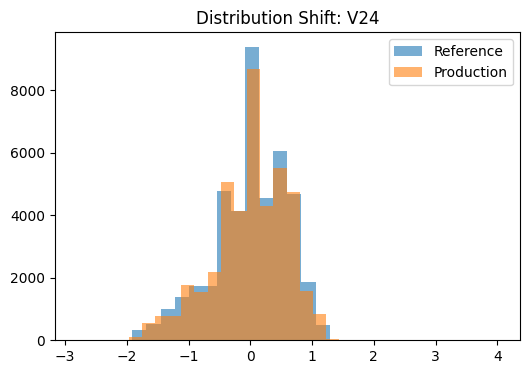

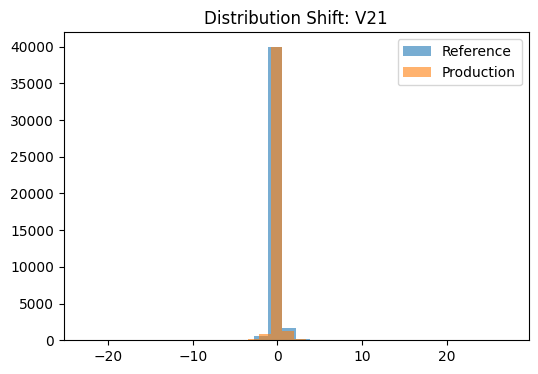

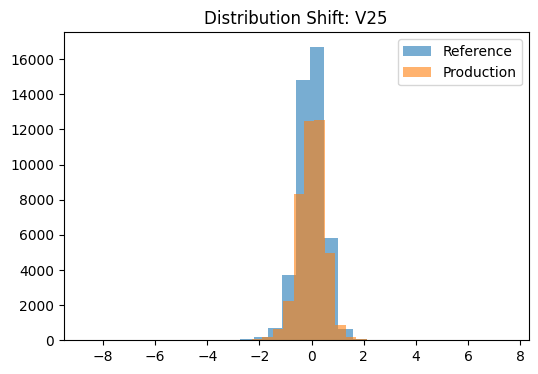

In [6]:
top_features = psi_df.sort_values("PSI", ascending=False).head(3).index

for feature in top_features:
    plt.figure(figsize=(6,4))
    
    plt.hist(ref[feature], bins=30, alpha=0.6, label="Reference")
    plt.hist(prod[feature], bins=30, alpha=0.6, label="Production")
    
    plt.title(f"Distribution Shift: {feature}")
    plt.legend()
    plt.show()


## Decision Layer

The decision layer translates drift metrics into a clear,
actionable outcome.

Rather than reacting to individual drift signals,
we evaluate the **overall severity** of drift across features
and decide whether intervention is required.

In [7]:
# Decision thresholds
SEVERE_PSI_THRESHOLD = 0.25
MAX_SEVERE_FEATURE_RATIO = 0.2  # 20%

total_features = len(psi_df)
severe_drift_features = (psi_df["PSI"] >= SEVERE_PSI_THRESHOLD).sum()
severe_ratio = severe_drift_features / total_features

print(f"Severe drift features: {severe_drift_features}/{total_features}")
print(f"Severe drift ratio: {severe_ratio:.2%}")

if severe_ratio > MAX_SEVERE_FEATURE_RATIO:
    final_verdict = "ALERT: Significant data drift detected. Retraining recommended."
else:
    final_verdict = "STABLE: Minor drift detected. Continue monitoring."

final_verdict

Severe drift features: 0/30
Severe drift ratio: 0.00%


'STABLE: Minor drift detected. Continue monitoring.'

## Final Summary

- Reference and production datasets were successfully compared
- PSI was calculated for all features
- Distribution shifts were visualized for the most drifted features
- A rule-based decision layer was applied

### Final Verdict
**STABLE** – Minor drift detected.  
No retraining is required at this stage.  
The system should continue monitoring future production batches.